# Figure 1: Analysis domains and split sensitivity

A two-panel figure combining the rainfall/VIMFC analysis domains with the land-grid-cell sensitivity to the P2 split start year.

In [1]:
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from cartopy.mpl.ticker import LatitudeFormatter, LongitudeFormatter
from matplotlib.patches import Rectangle

# ===== Figure customization controls =====
# Edit these values first when refining the layout and appearance.
FIGSIZE = (18, 7.2)  # Overall width and height in inches.
PANEL_WIDTH_RATIOS = (1.10, 1.20)  # Relative widths for (a) map and (b) line chart.
PANEL_BOX_ASPECT = 0.5  # Height / width for both panels; 0.5 gives a 2:1 panel.
FONT_SIZE = 20  # Shared size for titles, labels, ticks, and legend (points).
TITLE_PAD = 18  # Space between each panel and its title (points).
AXIS_LABEL_PAD = 8  # Space between an axis and its label (points).
MARKER_SIZE = 5  # Size of the circular markers in panel (b).
LINE_WIDTH = 1.8  # Line width in panel (b).
X_TICK_STEP = 4  # Years between x-axis labels in panel (b).
Y_TICK_STEP = 10  # Percentage interval between y-axis labels in panel (b).
EXPORT_DPI = 300  # Resolution for the PNG and PDF outputs.
SAVE_PADDING = 0.15  # White border around the saved figure (inches).

plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size': FONT_SIZE,
    'axes.labelsize': FONT_SIZE,
    'axes.titlesize': FONT_SIZE,
    'xtick.labelsize': FONT_SIZE,
    'ytick.labelsize': FONT_SIZE,
    'legend.fontsize': FONT_SIZE,
    'figure.dpi': 150,
    'axes.unicode_minus': False,
})

FIG1_DIR = Path('/Users/rizzie/Work/PaperENSO/Scripts_v2/Fig1')
DATA_PATH = FIG1_DIR / 'Identification_threshold_positive' / 'dcorr_nino34_djf_split_metrics_1981_2025.xlsx'
OUTPUT_DIR = FIG1_DIR
OUTPUT_DIR.mkdir(exist_ok=True)
PNG_PATH = OUTPUT_DIR / 'Fig1_combined.png'
# PDF output removed


In [2]:
metrics = pd.read_excel(DATA_PATH).sort_values('p2_start').reset_index(drop=True)

required_columns = {
    'p2_start',
    'percent_land_positive_change_gt_040',
    'percent_land_positive_change_gt_060',
    'percent_land_positive_change_gt_080',
}
missing_columns = required_columns.difference(metrics.columns)

print(f'Loaded {len(metrics)} split periods from {DATA_PATH.name}.')


Loaded 26 split periods from dcorr_nino34_djf_split_metrics_1981_2025.xlsx.


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)
/Users/rizzie/miniforge3/envs/climdata/lib/python3.11/site-packages/shapely/creation.py:730: RuntimeWarning: invalid value encountered in create_collection
  return lib.create_collection(geometries, np.intc(typ), out=out, **kwargs)


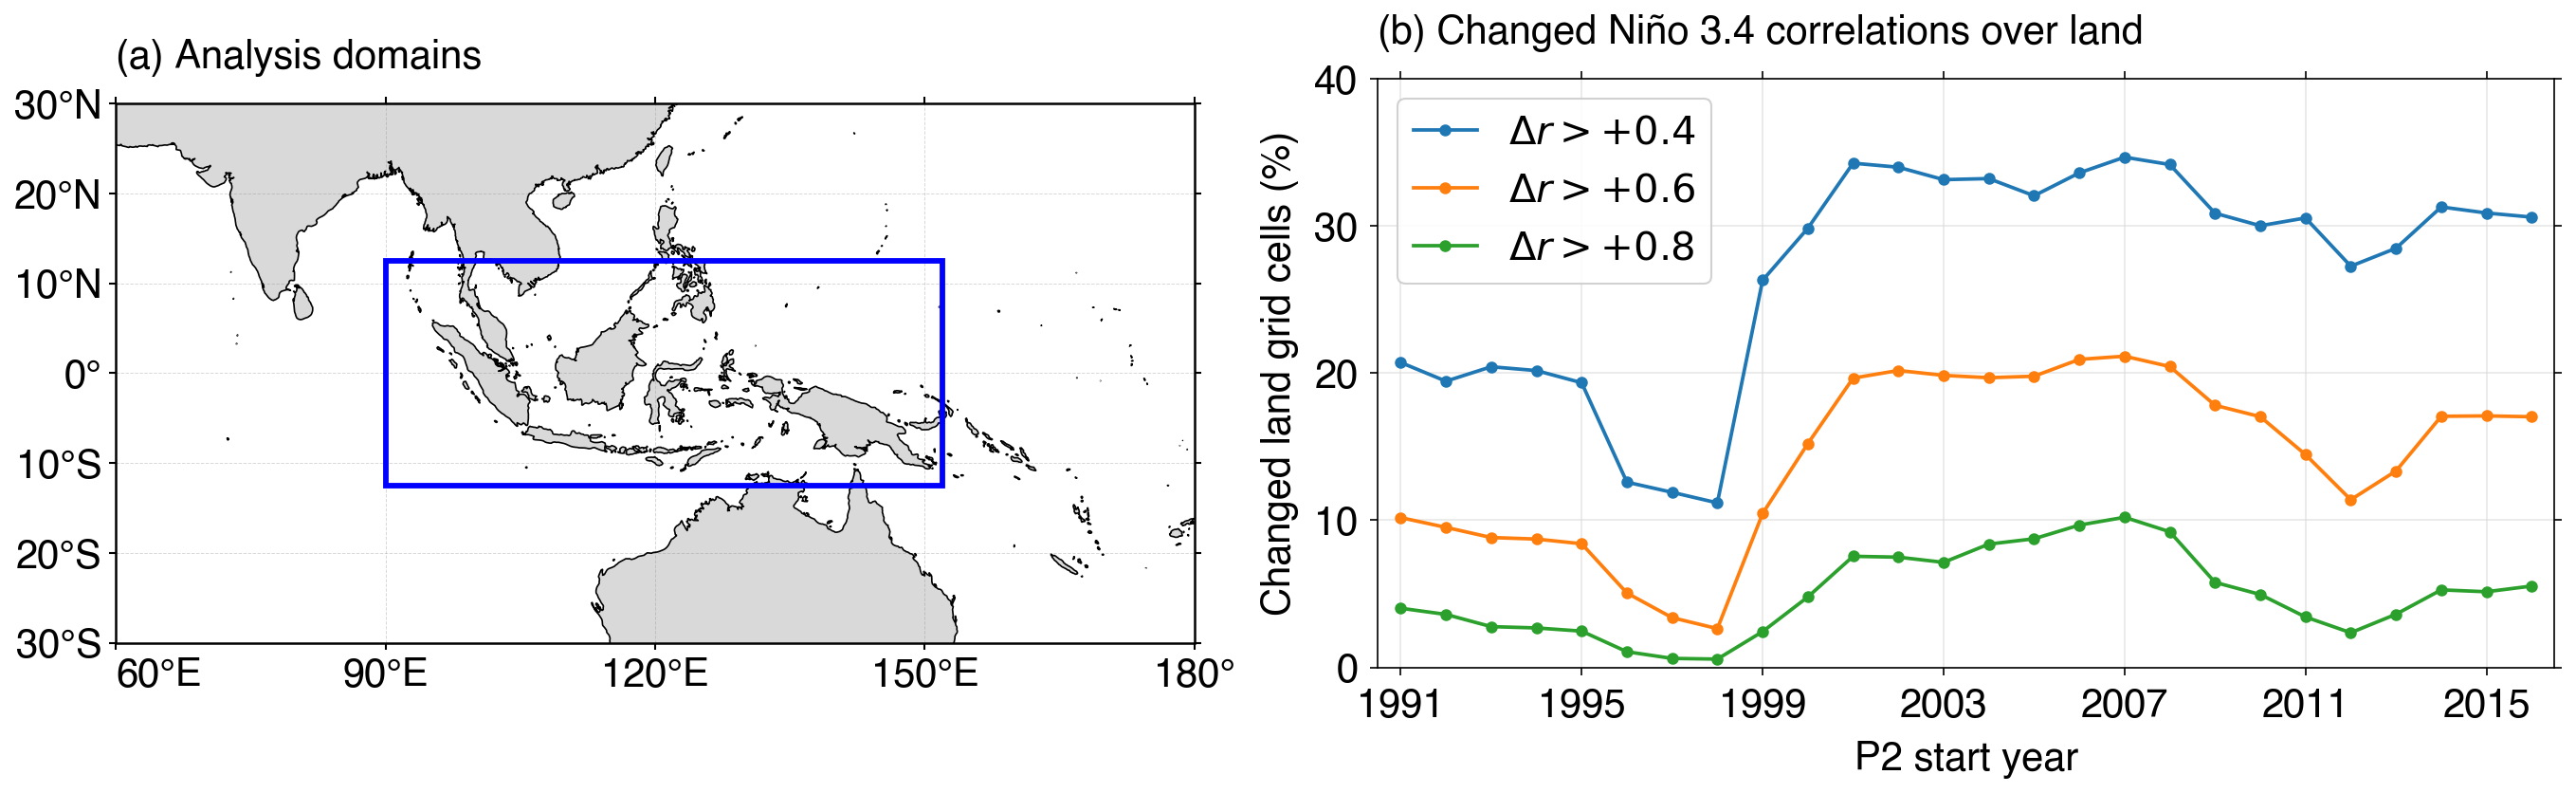

Saved: /Users/rizzie/Work/PaperENSO/Scripts_v2/Fig1/Fig1_combined.png


In [3]:
# Domain limits: [west, east, south, north] in degrees.
rainfall_domain = [90, 152, -12.5, 12.5]
vimfc_domain = [95, 125, -6, 2]
threshold_columns = {
    0.4: 'percent_land_positive_change_gt_040',
    0.6: 'percent_land_positive_change_gt_060',
    0.8: 'percent_land_positive_change_gt_080',
}

fig = plt.figure(figsize=FIGSIZE, constrained_layout=True)
grid = fig.add_gridspec(1, 2, width_ratios=PANEL_WIDTH_RATIOS)
map_ax = fig.add_subplot(grid[0], projection=ccrs.PlateCarree())
line_ax = fig.add_subplot(grid[1])
map_ax.set_box_aspect(PANEL_BOX_ASPECT)
line_ax.set_box_aspect(PANEL_BOX_ASPECT)

# (a) Analysis-domain map.
map_ax.set_extent([60, 180, -30, 30], crs=ccrs.PlateCarree())
land = cfeature.NaturalEarthFeature(
    'physical', 'land', '50m', facecolor='0.85', edgecolor='none'
)
map_ax.add_feature(land, zorder=0)
map_ax.coastlines(resolution='50m', color='black', linewidth=0.8, zorder=3)
xticks = [60, 90, 120, 150, 180]
yticks = [-30, -20, -10, 0, 10, 20, 30]
map_ax.set_xticks(xticks, crs=ccrs.PlateCarree())
map_ax.set_yticks(yticks, crs=ccrs.PlateCarree())
map_ax.xaxis.set_major_formatter(LongitudeFormatter(zero_direction_label=False))
map_ax.yaxis.set_major_formatter(LatitudeFormatter())
map_ax.tick_params(
    direction='out', top=True, right=True, labeltop=False, labelright=False,
    width=1.0, labelsize=FONT_SIZE
)
map_ax.gridlines(
    xlocs=xticks, ylocs=yticks, draw_labels=False, linewidth=0.45,
    color='0.55', alpha=0.35, linestyle='--', zorder=1
)
map_ax.add_patch(Rectangle(
    (rainfall_domain[0], rainfall_domain[2]),
    rainfall_domain[1] - rainfall_domain[0],
    rainfall_domain[3] - rainfall_domain[2],
    fill=False, edgecolor='blue', linewidth=2.8,
    transform=ccrs.PlateCarree(), zorder=4,
))
# map_ax.add_patch(Rectangle(
#     (vimfc_domain[0], vimfc_domain[2]),
#     vimfc_domain[1] - vimfc_domain[0],
#     vimfc_domain[3] - vimfc_domain[2],
#     fill=False, edgecolor='red', linewidth=2.8, linestyle=(0, (5, 3)),
#     transform=ccrs.PlateCarree(), zorder=4,
# ))
map_ax.set_title('(a) Analysis domains', loc='left', pad=TITLE_PAD, fontweight='medium')
for spine in map_ax.spines.values():
    spine.set_linewidth(1.2)

# (b) Split-sensitivity time series.
for threshold, column in threshold_columns.items():
    line_ax.plot(
        metrics['p2_start'], metrics[column], marker='o', markersize=MARKER_SIZE,
        linewidth=LINE_WIDTH, label=fr'$\Delta r > +{threshold}$'
    )
line_ax.set_title('(b) Changed Niño 3.4 correlations over land', loc='left', pad=TITLE_PAD)
line_ax.set_xlabel('P2 start year', labelpad=AXIS_LABEL_PAD)
line_ax.set_ylabel('Changed land grid cells (%)', labelpad=AXIS_LABEL_PAD)
line_ax.set_xlim(metrics['p2_start'].min() - 0.5, metrics['p2_start'].max() + 0.5)
line_ax.set_xticks(np.arange(metrics['p2_start'].min(), metrics['p2_start'].max() + 1, X_TICK_STEP))
line_ax.set_ylim(0, 40)
line_ax.set_yticks(np.arange(0, 41, Y_TICK_STEP))
line_ax.grid(True, color='0.85', linewidth=0.8, alpha=0.6)
line_ax.tick_params(
    axis='both', which='major', direction='out', length=4, width=0.8,
    top=True, right=True, pad=6
)
line_ax.legend(
    loc='upper left', frameon=True, framealpha=0.9, borderpad=0.4, handlelength=1.6
)

# Keep the left-most longitude label inside the map frame.
fig.canvas.draw()
for label in map_ax.get_xticklabels():
    if label.get_text().startswith('60'):
        label.set_ha('left')

fig.savefig(PNG_PATH, dpi=EXPORT_DPI, bbox_inches='tight', pad_inches=SAVE_PADDING)
plt.show()
print(f'Saved: {PNG_PATH}')
